## Access Station Lucinda Jetty Hourly Satlantic-Hyperocr Derived Product (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_hourly_satlantic-hyperocr_derived_product data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_hourly_satlantic-hyperocr_derived_product.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_hourly_satlantic_hyperocr_derived_product"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 733ms
Checked 155 packages in 2ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4355: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [8]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 889 ms, sys: 59.1 ms, total: 949 ms
Wall time: 1.95 s


In [9]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH = 461 ;
	TIME = 880314 ;

variables:
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_east ;
		LONGITUDE:valid_max = 180.0 ;
		LONGITUDE:valid_min = -180.0 ;
	float64 Rrs(WAVELENGTH, TIME) ;
		Rrs:ancillary_variables = Rrs_xflags relaz sza windspeed ;
		Rrs:cell_method = LATITUDE: LONGITUDE: TIME: point ;
		Rrs:intercept = 0.0 ;
		Rrs:long_name = Remote Sensing Reflectance ;
		Rrs:slope = 1.0 ;
		Rrs:units = sr^-1 ;
		Rrs:varname = Rrs ;
	int32 Rrs_xflags(WAVELENGTH, TIME) ;
		Rrs_xflags:anci

## Plot time coverage

In [10]:
aodn_dataset.get_temporal_extent()

(Timestamp('2019-09-18 05:14:01.122990848'),
 Timestamp('2019-10-01 06:43:59.121995776'))

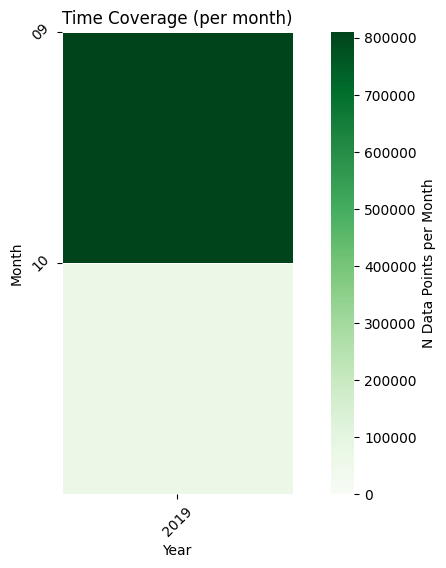

In [11]:
aodn_dataset.plot_time_coverage()

## Load Rrs Data

Access the Zarr store. Each file in this dataset covers roughly one hour at
**~0.3-second temporal resolution** (hundreds to thousands of spectra per file),
giving much finer temporal detail than the daily-averaged FV02 product.
Use this dataset to investigate **diurnal cycles**, **tidal signals**, and **within-day
Rrs variability** at Lucinda Jetty on the southern Great Barrier Reef.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

xds = aodn_dataset.zarr_store

time_vals = xds["TIME"].values
t_min = pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
t_max = pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")
wl    = xds["WAVELENGTH"].values

print(f"Dataset: {xds.dims['TIME']:,} time steps from {t_min} to {t_max}")
print(f"Wavelength range: {wl.min():.0f}–{wl.max():.0f} nm ({len(wl)} bands)")
dt_s = np.median(np.diff(time_vals[:2000]).astype("timedelta64[ms]").astype(float)) / 1000
print(f"Typical time interval: {dt_s:.1f} s  (~{dt_s/60:.1f} min)")
print(xds["Rrs"])


Dataset: 880,314 time steps from 2019-09-18 to 2019-10-01
Wavelength range: 350–810 nm (461 bands)
Typical time interval: 0.3 s  (~0.0 min)
<xarray.DataArray 'Rrs' (WAVELENGTH: 461, TIME: 880314)> Size: 3GB
[405824754 values with dtype=float64]
Coordinates:
    LATITUDE    float64 8B ...
    LONGITUDE   float64 8B ...
  * TIME        (TIME) datetime64[ns] 7MB 2019-09-18T05:14:01.122990848 ... 2...
  * WAVELENGTH  (WAVELENGTH) float64 4kB 350.0 351.0 352.0 ... 808.0 809.0 810.0
    relaz       float64 8B ...
    sza         (TIME) float64 7MB ...
    windspeed   (TIME) float64 7MB ...
Attributes:
    ancillary_variables:  Rrs_xflags relaz sza windspeed
    cell_method:          LATITUDE: LONGITUDE: TIME: point
    intercept:            0.0
    long_name:            Remote Sensing Reflectance
    slope:                1.0
    units:                sr^-1
    varname:              Rrs


## Rrs Hyperspectral Signatures

Full 350–810 nm spectra at selected dates (hourly median), with standard ocean-colour
satellite band positions overlaid. The spectral shape reflects the optical properties
of coastal water at Lucinda Jetty: green-peak turbid signature dominated by
sediment scattering and CDOM absorption.


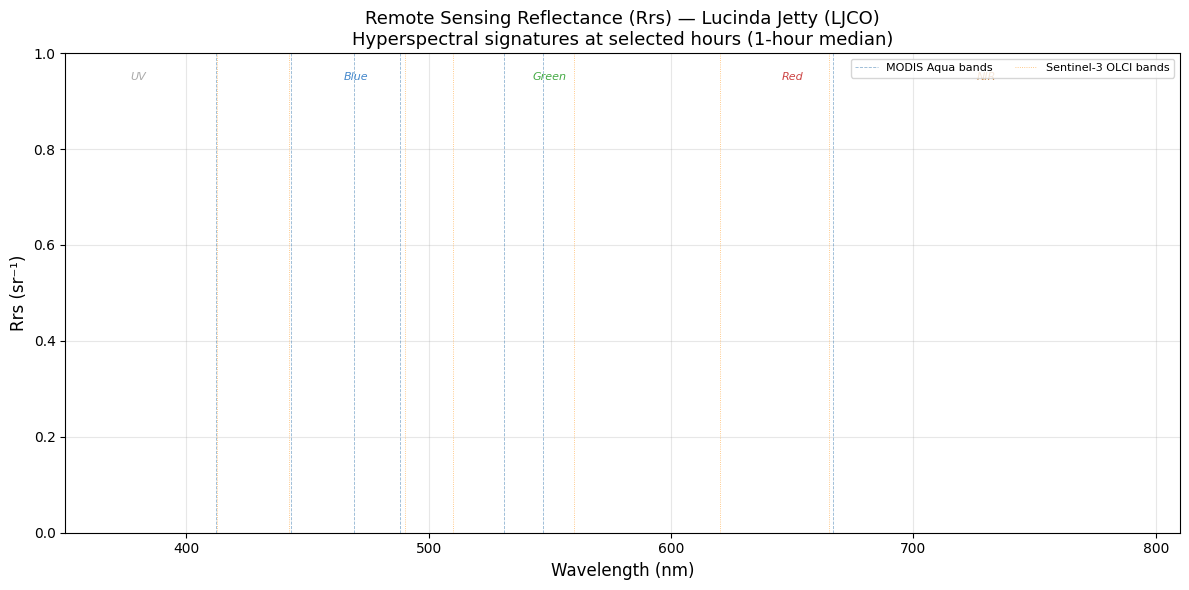

In [9]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl = xds["WAVELENGTH"].values
rrs_da   = xds["Rrs"].sel(TIME=slice(DATE_START, DATE_END))
# Bin to 1-hour blocks first
rrs_1h   = rrs_da.resample(TIME="1h").median("TIME").astype(float)

# Pick 6 evenly-spaced hours with valid data
good_t = rrs_1h.TIME.values[
    np.where(~np.all(np.isnan(rrs_1h.values), axis=0))[0]
]
n_show = min(6, len(good_t))
pick_idx = np.linspace(0, len(good_t) - 1, n_show, dtype=int)
sample_times = good_t[pick_idx]

MODIS_BANDS = [412, 443, 469, 488, 531, 547, 667]
OLCI_BANDS  = [412.5, 442.5, 490, 510, 560, 620, 665]

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, t in enumerate(sample_times):
    spec  = rrs_1h.sel(TIME=t, method="nearest").values
    label = pd.Timestamp(t).strftime("%Y-%m-%d %H:%M UTC")
    ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)

drawn = set()
for b in MODIS_BANDS:
    lbl = "MODIS Aqua bands" if "MODIS" not in drawn else "_"
    drawn.add("MODIS")
    ax.axvline(b, color="steelblue", lw=0.6, ls="--", alpha=0.6, label=lbl)
for b in OLCI_BANDS:
    lbl = "Sentinel-3 OLCI bands" if "OLCI" not in drawn else "_"
    drawn.add("OLCI")
    ax.axvline(b, color="darkorange", lw=0.6, ls=":", alpha=0.6, label=lbl)

for xpos, txt, col in [(380,"UV","#aaa"),(470,"Blue","#4488cc"),
                        (550,"Green","#44aa44"),(650,"Red","#cc4444"),
                        (730,"NIR","#cc8844")]:
    ax.text(xpos, ax.get_ylim()[1]*0.96 if ax.get_ylim()[1]>0 else 0.018,
            txt, ha="center", va="top", fontsize=8, color=col, style="italic")

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Rrs (sr⁻¹)", fontsize=12)
ax.set_title(
    "Remote Sensing Reflectance (Rrs) — Lucinda Jetty (LJCO)\n"
    "Hyperspectral signatures at selected hours (1-hour median)",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Rrs Hovmöller at Hourly Resolution

Wavelength–time heatmap of Rrs binned to **1-hour intervals**.
The sub-daily resolution reveals:
- **Diurnal pattern**: daytime Rrs peaks vs. near-zero night values
- **Day-to-day variability**: cloudy days show suppressed or noisier Rrs
- **Seasonal envelope**: green-dominated signature intensifies in the tropical wet season (DJF)

Limit to a shorter window (e.g. one month) for best visual clarity.


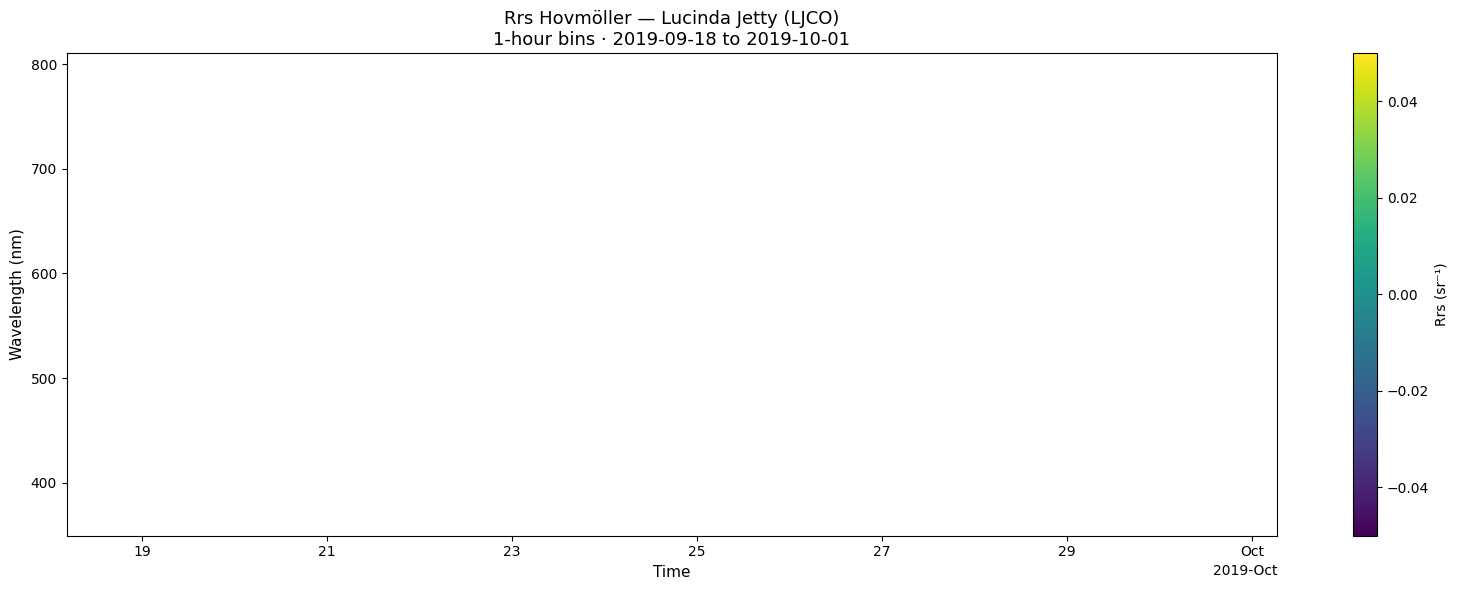

In [10]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
t_min_dt = pd.Timestamp(time_vals[0])
t_max_dt = pd.Timestamp(time_vals[-1])
# Default: show up to 90 days to keep the plot readable
if not DATE_START:
    DATE_START = t_min_dt.strftime("%Y-%m-%d")
if not DATE_END:
    DATE_END = min(t_max_dt, t_min_dt + pd.Timedelta(days=90)).strftime("%Y-%m-%d")

wl    = xds["WAVELENGTH"].values
rrs_1h = (
    xds["Rrs"]
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME="1h").median("TIME")
    .astype(float)
)

fig, ax = plt.subplots(figsize=(16, 6))
rrs_1h.plot(
    x="TIME", y="WAVELENGTH",
    ax=ax, robust=True,
    cmap="viridis",
    cbar_kwargs={"label": "Rrs (sr⁻¹)"},
)
ax.set_title(
    "Rrs Hovmöller — Lucinda Jetty (LJCO)\n"
    f"1-hour bins · {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Wavelength (nm)", fontsize=11)

for wl_m, lbl in [(443,"443 nm"),(555,"555 nm"),(665,"665 nm")]:
    ax.axhline(wl_m, color="white", lw=0.7, ls="--", alpha=0.7)
    ax.text(pd.Timestamp(DATE_START), wl_m+4, lbl,
            color="white", fontsize=7, va="bottom")
plt.tight_layout()
plt.show()


## Diurnal Rrs Cycle

Climatological mean Rrs at four ocean-colour wavelengths as a function of **hour-of-day (UTC)**.
All data are folded onto a 0–23 h axis to reveal the diurnal signal:

- Solar elevation drives the bulk of the diurnal signal (higher sun → lower air–sea interface reflectance → higher Rrs)
- Any asymmetry between morning and afternoon hours may reflect **sea-breeze-driven turbulence** or tidal mixing effects
- Near-zero values at night confirm that the QC filters correctly exclude twilight measurements

*Note: Lucinda Jetty is at UTC+10, so local noon ≈ UTC 02:00.*


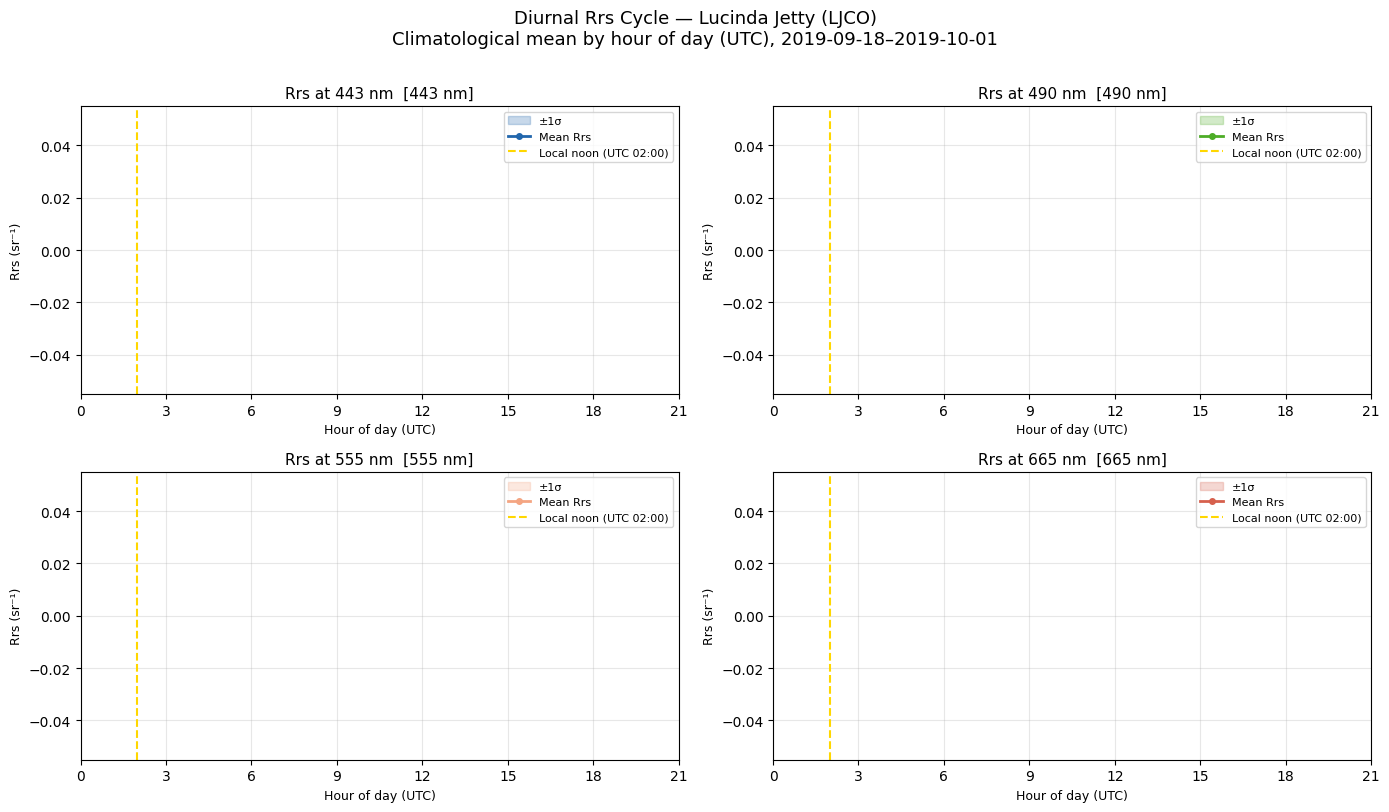

In [11]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

KEY_WL = {"443 nm": 443, "490 nm": 490, "555 nm": 555, "665 nm": 665}
COLORS = {"443 nm": "#2166ac", "490 nm": "#4dac26",
          "555 nm": "#f4a582", "665 nm": "#d6604d"}

wl_arr = xds["WAVELENGTH"].values
sub    = xds.sel(TIME=slice(DATE_START, DATE_END))
# Bin to 1h, extract hour-of-day
rrs_1h  = sub["Rrs"].resample(TIME="1h").median("TIME").astype(float)
hours   = pd.to_datetime(rrs_1h.TIME.values).hour
rrs_np  = rrs_1h.values   # (WAVELENGTH, TIME)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (label, target_wl) in zip(axes, KEY_WL.items()):
    idx  = int(np.argmin(np.abs(wl_arr - target_wl)))
    ts   = rrs_np[idx, :]
    color = COLORS[label]
    # Group by hour
    mean_h = np.array([np.nanmean(ts[hours == h]) for h in range(24)])
    std_h  = np.array([np.nanstd( ts[hours == h]) for h in range(24)])
    n_h    = np.array([np.sum(~np.isnan(ts[hours == h])) for h in range(24)])

    h_axis = np.arange(24)
    ax.fill_between(h_axis, mean_h - std_h, mean_h + std_h,
                    alpha=0.25, color=color, label="±1σ")
    ax.plot(h_axis, mean_h, color=color, lw=2, marker="o", ms=4, label="Mean Rrs")
    # Mark local noon (UTC+10 → UTC 02:00)
    ax.axvline(2, color="gold", lw=1.5, ls="--", label="Local noon (UTC 02:00)")
    ax.set_title(f"Rrs at {wl_arr[idx]:.0f} nm  [{label}]", fontsize=11)
    ax.set_xlabel("Hour of day (UTC)", fontsize=9)
    ax.set_ylabel("Rrs (sr⁻¹)", fontsize=9)
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Diurnal Rrs Cycle — Lucinda Jetty (LJCO)\n"
    f"Climatological mean by hour of day (UTC), {DATE_START}–{DATE_END}",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


## Ocean-Colour Band Ratios at Hourly Resolution

Band ratios computed from 1-hour median Rrs values:

| Ratio | Proxy |
|---|---|
| Rrs(490) / Rrs(555) | Turbidity / CDOM index — higher = clearer water |
| Rrs(443) / Rrs(555) | Phytoplankton / CDOM absorption — lower = more absorption |

The finer temporal resolution compared to the daily product reveals sub-daily
turbidity events (tidal resuspension, storm runoff pulses) superimposed on the
seasonal trend.


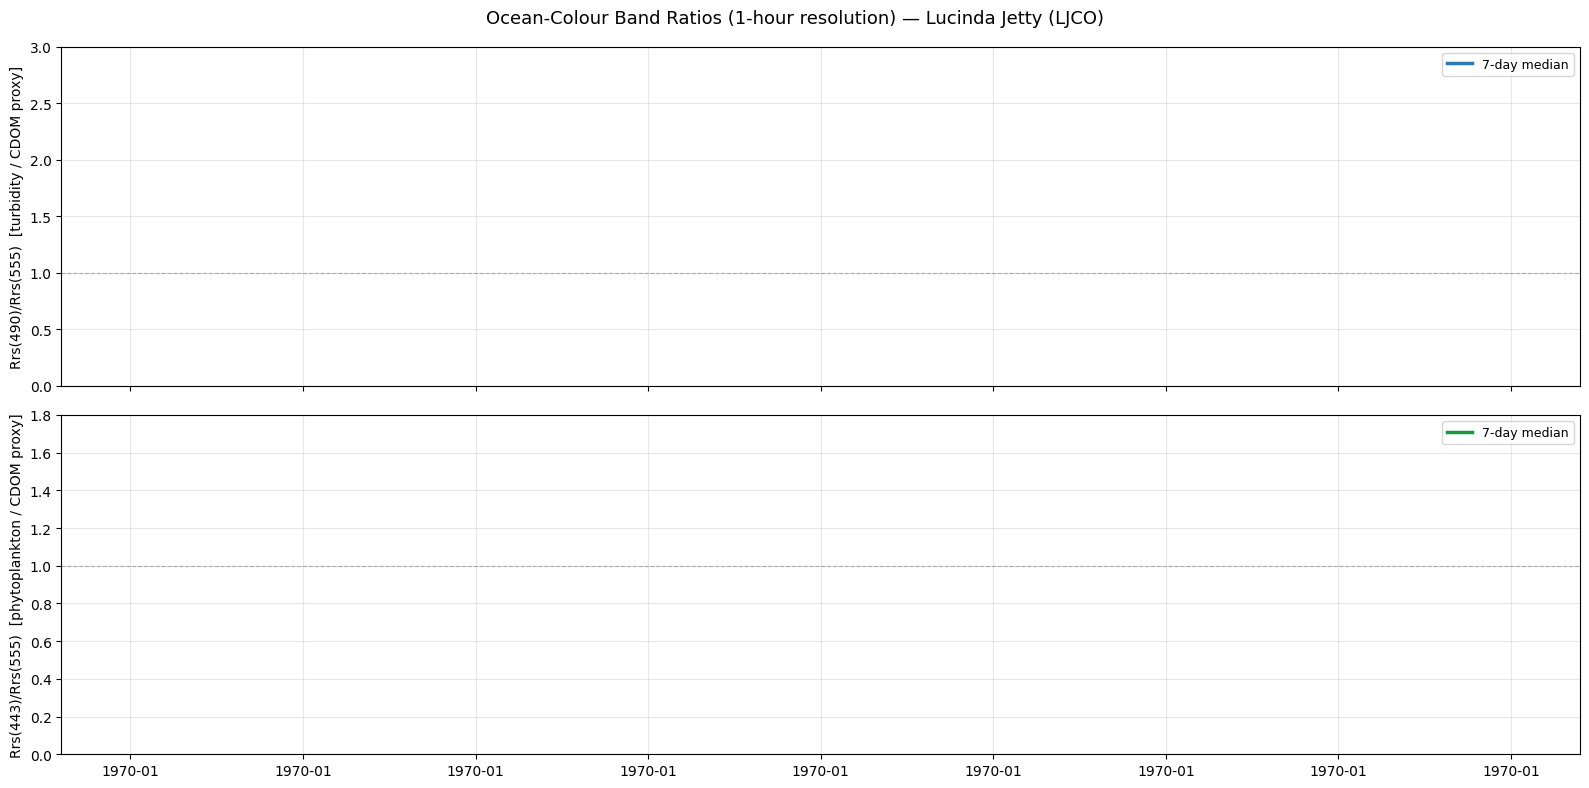

In [12]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH"].values
sub    = xds.sel(TIME=slice(DATE_START, DATE_END))
rrs_1h = sub["Rrs"].resample(TIME="1h").median("TIME").astype(float)
t_1h   = pd.to_datetime(rrs_1h.TIME.values)

def rrs_at(wl_target):
    idx = int(np.argmin(np.abs(wl_arr - wl_target)))
    return rrs_1h.isel(WAVELENGTH=idx).values

rrs_443 = rrs_at(443); rrs_490 = rrs_at(490); rrs_555 = rrs_at(555)

r490_555 = np.where(rrs_555 > 0, rrs_490 / rrs_555, np.nan)
r443_555 = np.where(rrs_555 > 0, rrs_443 / rrs_555, np.nan)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, ratio, label, color, ylim in [
    (ax1, r490_555, "Rrs(490)/Rrs(555)  [turbidity / CDOM proxy]",   "#2c7bb6", (0, 3.0)),
    (ax2, r443_555, "Rrs(443)/Rrs(555)  [phytoplankton / CDOM proxy]", "#1a9641", (0, 1.8)),
]:
    valid = ~np.isnan(ratio)
    ax.scatter(t_1h[valid], ratio[valid], s=4, alpha=0.3, color=color)
    # 7-day rolling median (finer than 30d to show sub-monthly events)
    roll = pd.Series(ratio, index=t_1h).rolling("7D", center=True).median()
    ax.plot(roll.index, roll.values, color=color, lw=2.5, label="7-day median")
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(ylim)
    ax.axhline(1.0, color="grey", lw=0.8, ls="--", alpha=0.6)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Ocean-Colour Band Ratios (1-hour resolution) — Lucinda Jetty (LJCO)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


## Seasonal Mean Rrs Spectra

Mean (±1σ) Rrs spectra grouped by austral season, computed from **1-hour median** spectra.
The high temporal density of the hourly product provides more observations per season
than the daily product, yielding tighter uncertainty envelopes.

- **DJF** (Dec–Feb) — wet season: highest turbidity, CDOM loading from river runoff
- **MAM** (Mar–May) — transition: declining turbidity
- **JJA** (Jun–Aug) — dry season: clearest water, lower scattering
- **SON** (Sep–Nov) — pre-wet: increasing primary production

Satellite band centres (MODIS Aqua, Sentinel-3 OLCI) are overlaid for direct
comparison with spaceborne ocean-colour products.


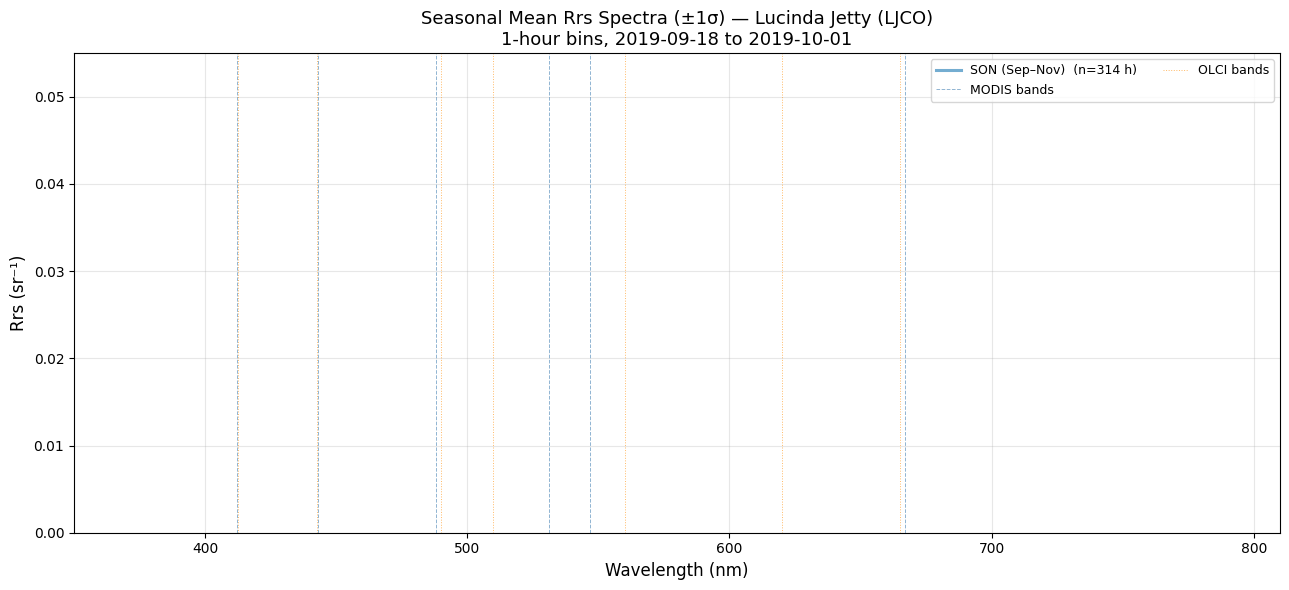

In [13]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH"].values
rrs_1h = (
    xds["Rrs"]
    .sel(TIME=slice(DATE_START, DATE_END))
    .resample(TIME="1h").median("TIME")
    .astype(float)
)
months = pd.to_datetime(rrs_1h.TIME.values).month
rrs_np = rrs_1h.values  # (WAVELENGTH, TIME)

seasons = {
    "DJF (Dec–Feb)": ([12, 1, 2],  "#d73027"),
    "MAM (Mar–May)": ([3, 4, 5],   "#fc8d59"),
    "JJA (Jun–Aug)": ([6, 7, 8],   "#4575b4"),
    "SON (Sep–Nov)": ([9, 10, 11], "#74add1"),
}

SAT_BANDS = [
    (412,  "MODIS",  "steelblue"), (443,  "MODIS",  "steelblue"),
    (488,  "MODIS",  "steelblue"), (531,  "MODIS",  "steelblue"),
    (547,  "MODIS",  "steelblue"), (667,  "MODIS",  "steelblue"),
    (412.5,"OLCI",   "darkorange"),(442.5,"OLCI",   "darkorange"),
    (490,  "OLCI",   "darkorange"),(510,  "OLCI",   "darkorange"),
    (560,  "OLCI",   "darkorange"),(620,  "OLCI",   "darkorange"),
    (665,  "OLCI",   "darkorange"),
]

fig, ax = plt.subplots(figsize=(13, 6))
drawn_labels = set()

for season, (month_list, color) in seasons.items():
    mask = np.isin(months, month_list)
    if mask.sum() == 0:
        continue
    s_data = rrs_np[:, mask]
    mean_s = np.nanmean(s_data, axis=1)
    std_s  = np.nanstd(s_data,  axis=1)
    n_obs  = mask.sum()
    ax.plot(wl_arr, mean_s, color=color, lw=2.2, label=f"{season}  (n={n_obs:,} h)")
    ax.fill_between(wl_arr, mean_s - std_s, mean_s + std_s,
                    color=color, alpha=0.15)

for wl_b, sat, col in SAT_BANDS:
    lbl = f"{sat} bands" if (sat, col) not in drawn_labels else "_"
    drawn_labels.add((sat, col))
    ax.axvline(wl_b, color=col, lw=0.7, ls="--" if sat=="MODIS" else ":", alpha=0.6, label=lbl)

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Rrs (sr⁻¹)", fontsize=12)
ax.set_title(
    "Seasonal Mean Rrs Spectra (±1σ) — Lucinda Jetty (LJCO)\n"
    f"1-hour bins, {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
